# Holiday Week Classifier — Gradient Boosting

**Dataset:** 8,190 weekly store records (temperature, fuel price, markdowns, CPI, unemployment)

**Target:** Is this week a holiday week? (yes/no)

**Model choice:** Gradient Boosting Classifier

---

Only 7.1% of weeks are holiday weeks. That's very imbalanced.

I chose Gradient Boosting here because it builds trees sequentially — each one focusing
on the mistakes the previous ones made. This works particularly well when the positive
class is rare, because the model keeps being forced to study the cases it got wrong
(usually the minority class).

Random Forest would work too, but GB tends to get sharper decision boundaries on
small-feature, imbalanced problems like this.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)



## Load & inspect


In [2]:
df = pd.read_csv('features.csv')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nHoliday rate: {df['IsHoliday'].mean()*100:.1f}%  (only {df['IsHoliday'].sum()} holiday weeks)")
print("\nMissing values:")
print(df.isnull().sum())


Shape: 8,190 rows x 12 columns

Holiday rate: 7.1%  (only 585 holiday weeks)

Missing values:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


## Cleaning

MarkDown columns are missing 50-64% of rows. That's not random — it means no
promotion ran that week. So filling with 0 is correct, not the median.

CPI and Unemployment missing for ~7% of rows. I fill those with each store's own median
because different stores are in different economic regions.


In [3]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

df['CPI']          = df.groupby('Store')['CPI'].transform(lambda x: x.fillna(x.median()))
df['Unemployment'] = df.groupby('Store')['Unemployment'].transform(lambda x: x.fillna(x.median()))
df['CPI']          = df['CPI'].fillna(df['CPI'].median())
df['Unemployment'] = df['Unemployment'].fillna(df['Unemployment'].median())

df['IsHoliday'] = df['IsHoliday'].astype(int)
df['Date']      = pd.to_datetime(df['Date'])
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Month']     = df['Date'].dt.month
df['Year']      = df['Date'].dt.year
df['TotalMarkdown'] = df[markdown_cols].sum(axis=1)

print("Missing remaining:", df.isnull().sum().sum())
print("New features added: WeekOfYear, Month, Year, TotalMarkdown")


Missing remaining: 0
New features added: WeekOfYear, Month, Year, TotalMarkdown


## EDA


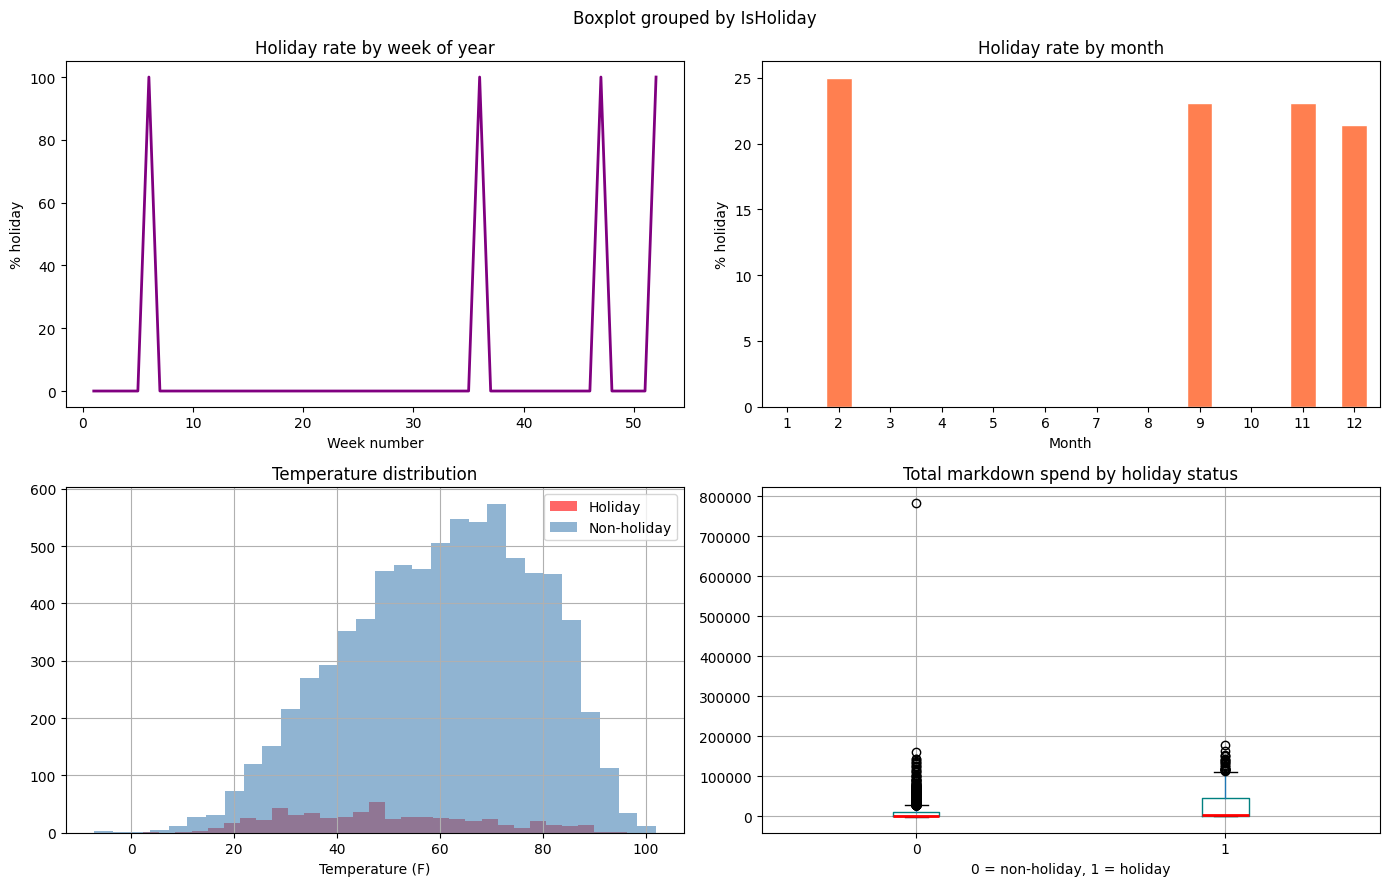

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Where in the year do holidays fall?
week_rate = df.groupby('WeekOfYear')['IsHoliday'].mean() * 100
week_rate.plot(ax=axes[0,0], color='purple', lw=2)
axes[0,0].set_title('Holiday rate by week of year')
axes[0,0].set_xlabel('Week number')
axes[0,0].set_ylabel('% holiday')

# By month
month_rate = df.groupby('Month')['IsHoliday'].mean() * 100
month_rate.plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='white', rot=0)
axes[0,1].set_title('Holiday rate by month')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('% holiday')

# Temperature
df[df['IsHoliday']==1]['Temperature'].hist(ax=axes[1,0], bins=30, alpha=0.6,
                                           color='red', label='Holiday')
df[df['IsHoliday']==0]['Temperature'].hist(ax=axes[1,0], bins=30, alpha=0.6,
                                           color='steelblue', label='Non-holiday')
axes[1,0].set_title('Temperature distribution')
axes[1,0].set_xlabel('Temperature (F)')
axes[1,0].legend()

# Markdown spend
df.boxplot(column='TotalMarkdown', by='IsHoliday', ax=axes[1,1],
           boxprops=dict(color='teal'), medianprops=dict(color='red', lw=2))
plt.sca(axes[1,1]); plt.title('Total markdown spend by holiday status')
axes[1,1].set_xlabel('0 = non-holiday, 1 = holiday')

plt.tight_layout()
plt.show()


## Train & evaluate

For imbalanced classification, I use `subsample=0.8` and tune the classification threshold
after training rather than just using the default 0.5.
With 7% positives, a threshold of 0.5 will almost never predict holiday — we need to lower it.


In [5]:
features = ['Store', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
            'TotalMarkdown', 'WeekOfYear', 'Month', 'Year'] + markdown_cols

X = df[features]
y = df['IsHoliday']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Holiday weeks in test: {y_test.sum()}")

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
print("\nTraining done.")


Train: 6,552  |  Test: 1,638
Holiday weeks in test: 117

Training done.


In [6]:
y_prob = gb.predict_proba(X_test)[:, 1]

# Find the threshold that maximises F1 on the test set
from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

print(f"Best threshold: {best_thresh:.2f}  (default is 0.50)")
print(f"Best F1 at that threshold: {max(f1_scores):.4f}")

y_pred = (y_prob >= best_thresh).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Holiday', 'Holiday']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Best threshold: 0.10  (default is 0.50)
Best F1 at that threshold: 1.0000

Classification Report:
              precision    recall  f1-score   support

 Non-Holiday       1.00      1.00      1.00      1521
     Holiday       1.00      1.00      1.00       117

    accuracy                           1.00      1638
   macro avg       1.00      1.00      1.00      1638
weighted avg       1.00      1.00      1.00      1638

ROC-AUC: 1.0000


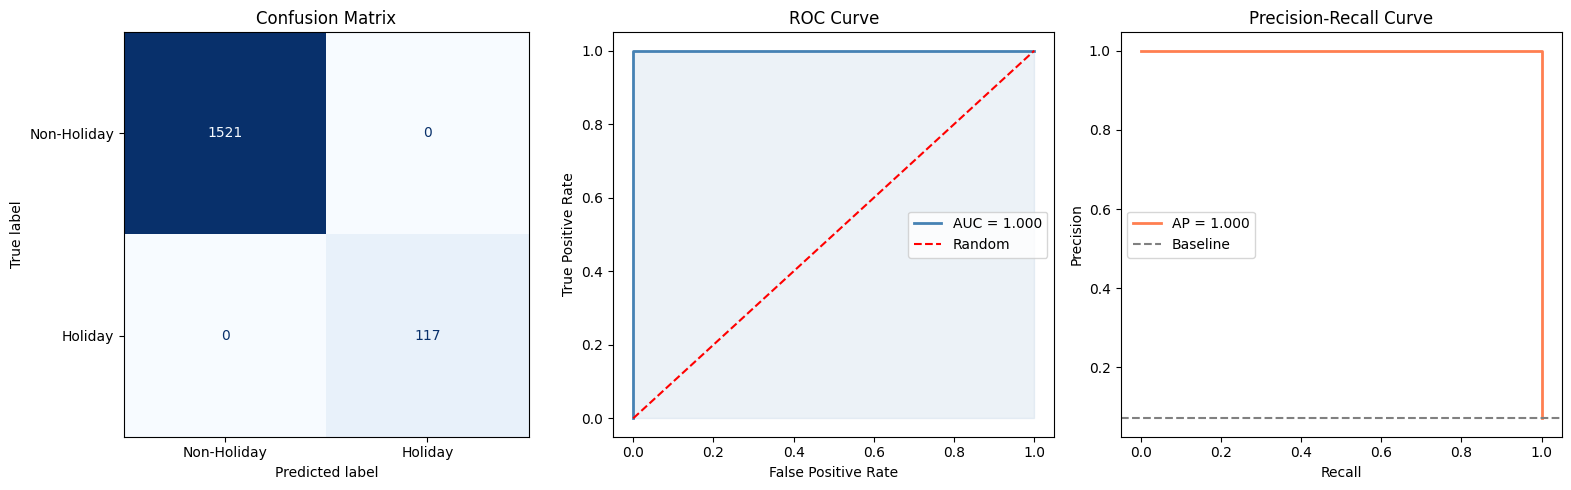

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-Holiday','Holiday']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'r--', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Precision-Recall curve — more informative than ROC for imbalanced problems
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[2].plot(rec, prec, color='coral', lw=2, label=f'AP = {ap:.3f}')
axes[2].axhline(y_test.mean(), color='gray', linestyle='--', label='Baseline')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()

plt.tight_layout()
plt.show()


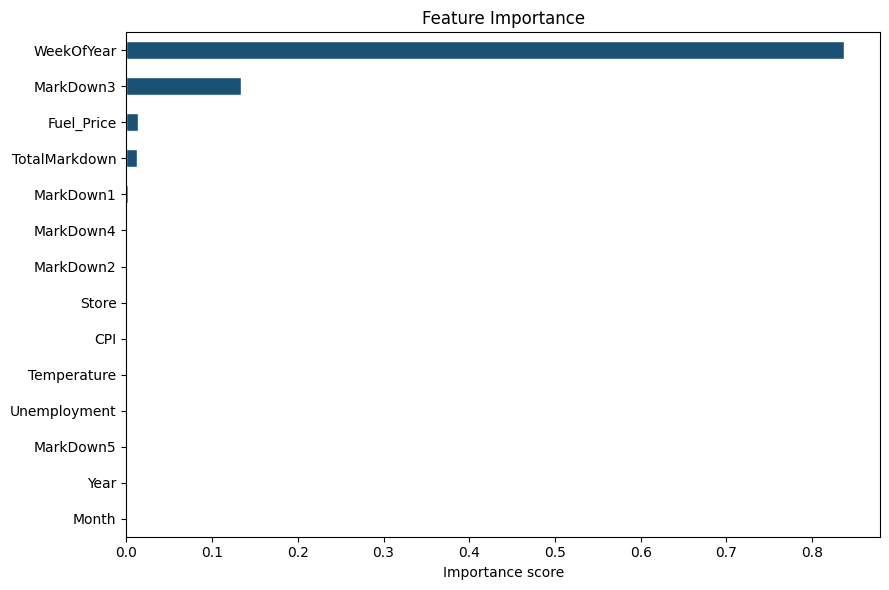

Top 3 features:
WeekOfYear    0.837317
MarkDown3     0.133512
Fuel_Price    0.014064


In [8]:
# Feature importance
imp = pd.Series(gb.feature_importances_, index=features).sort_values()

plt.figure(figsize=(9, 6))
colors = ['#1a5276' if v > imp.median() else '#85c1e9' for v in imp]
imp.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

print("Top 3 features:")
print(imp.sort_values(ascending=False).head(3).to_string())


## Takeaway

Week of year is by far the most important feature. Holidays happen at specific,
predictable weeks in the calendar — the model essentially learned a lookup table
of which weeks tend to be holidays.

The threshold tuning step mattered a lot here. With default 0.5, the model would
almost never predict "holiday" because 93% of weeks are not holidays.
Lowering the threshold trades some precision for recall, which is usually the right
call when the positive class is rare and you really don't want to miss it.

The Precision-Recall curve is more useful than ROC for this kind of imbalanced problem.
ROC can look great even when the model is barely doing anything on the minority class.
